In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cftime
import warnings
from datetime import datetime

warnings.filterwarnings(action = 'ignore', category = RuntimeWarning)

In [2]:
#casename = 'test_US-SPR_ICB1850CNRDCTCBC_ad_spinup'
casename = '20230601_plot16_US-SPR_ICB20TRCNPRDCTCBC'
file_list = [os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', 
                         f'{casename}.clm2.h2.{y:04g}-01-01-00000.nc') for y in range(2015, 2021)] # range(5, 15)]

hr = xr.open_mfdataset(file_list, decode_times=False)
hr['time'] = xr.decode_cf(hr, decode_times=True, decode_coords=True)['time']

file_list_env = [os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', casename, 'run', 
                         f'{casename}.clm2.h1.{y:04g}-01-01-00000.nc') for y in range(2015, 2021)] # range(5, 15)]
hr2 = xr.open_mfdataset(file_list_env, decode_times=False)
hr2['time'] = xr.decode_cf(hr2, decode_times=True, decode_coords=True)['time']

Text(0.5, 1.0, 'TSOI Layer 3')

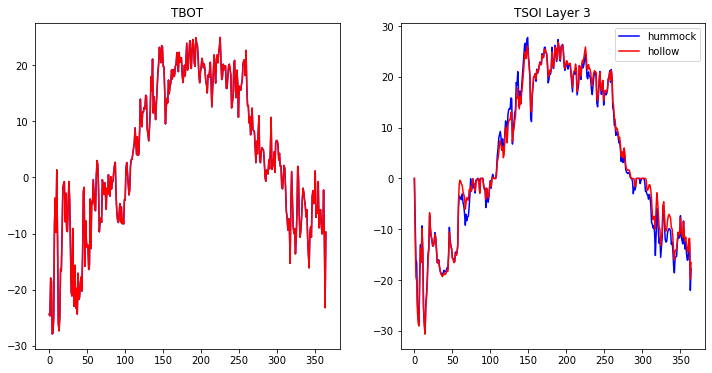

In [4]:
fig, axes = plt.subplots(1, 2, figsize = (12,6), sharex = True)
ax = axes[0]
ax.plot((hr2['TBOT'] - 273.15).groupby('time.month').mean()[:, 0], '-b', label = 'hummock')
ax.plot((hr2['TBOT'] - 273.15).groupby('time.month').mean()[:, 1], '-r', label = 'hollow')
ax.set_title('TBOT')
ax = axes[1]
ax.plot((hr2['TSOI'] - 273.15).groupby('time.month').mean()[:, 2, 0], '-b', label = 'hummock')
ax.plot((hr2['TSOI'] - 273.15).groupby('time.month').mean()[:, 2, 1], '-r', label = 'hollow')
ax.legend()
ax.set_title('TSOI Layer 3')

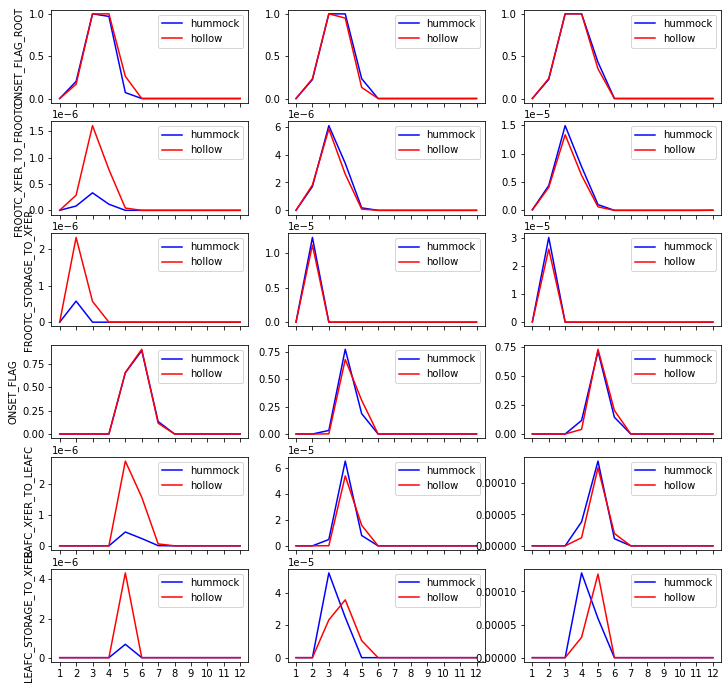

In [6]:
fig, axes = plt.subplots(6, 3, figsize = (12,12), sharex = True)
for i, pft in enumerate([2, 3, 11]):
    temp = hr['ONSET_FLAG_ROOT'].groupby('time.month').mean().compute()
    ax = axes[0, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('ONSET_FLAG_ROOT')

    temp = hr['FROOTC_XFER_TO_FROOTC'].groupby('time.month').mean().compute()
    ax = axes[1, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('FROOTC_XFER_TO_FROOTC')

    temp = hr['FROOTC_STORAGE_TO_XFER'].groupby('time.month').mean().compute()
    ax = axes[2, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('FROOTC_STORAGE_TO_XFER')

    temp = hr['ONSET_FLAG'].groupby('time.month').mean().compute()
    ax = axes[3, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('ONSET_FLAG')

    temp = hr['LEAFC_XFER_TO_LEAFC'].groupby('time.month').mean().compute()
    ax = axes[4, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('LEAFC_XFER_TO_LEAFC')

    temp = hr['LEAFC_STORAGE_TO_XFER'].groupby('time.month').mean().compute()
    ax = axes[5, i]
    ax.plot(temp[:, pft], '-b', label = 'hummock')
    ax.plot(temp[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('LEAFC_STORAGE_TO_XFER')

    ax.set_xlim([-0.5,11.5])
    ax.set_xticks(range(12))
    ax.set_xticklabels(range(1,13))

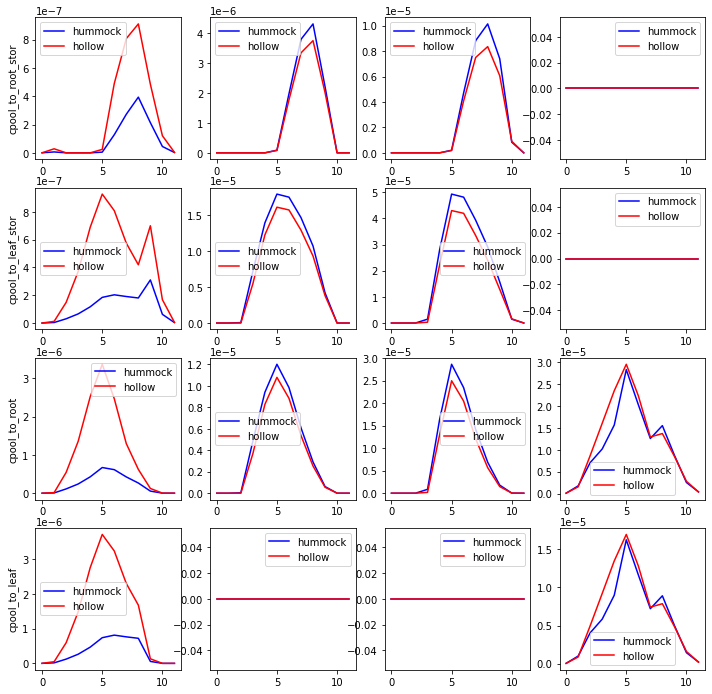

In [7]:
fig, axes = plt.subplots(4, 4, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11, 12]):
    ax = axes[0, i]
    ax.plot(hr['CPOOL_TO_FROOTC_STORAGE'].groupby('time.month').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['CPOOL_TO_FROOTC_STORAGE'].groupby('time.month').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('cpool_to_root_stor')

    ax = axes[1, i]
    ax.plot(hr['CPOOL_TO_LEAFC_STORAGE'].groupby('time.month').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['CPOOL_TO_LEAFC_STORAGE'].groupby('time.month').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    if i == 0:
        ax.set_ylabel('cpool_to_leaf_stor')

    ax = axes[2, i]
    ax.plot(hr['CPOOL_TO_FROOTC'].groupby('time.month').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['CPOOL_TO_FROOTC'].groupby('time.month').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    if i == 0:
        ax.set_ylabel('cpool_to_root')

    ax = axes[3, i]
    ax.plot(hr['CPOOL_TO_LEAFC'].groupby('time.month').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['CPOOL_TO_LEAFC'].groupby('time.month').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    if i == 0:
        ax.set_ylabel('cpool_to_leaf')

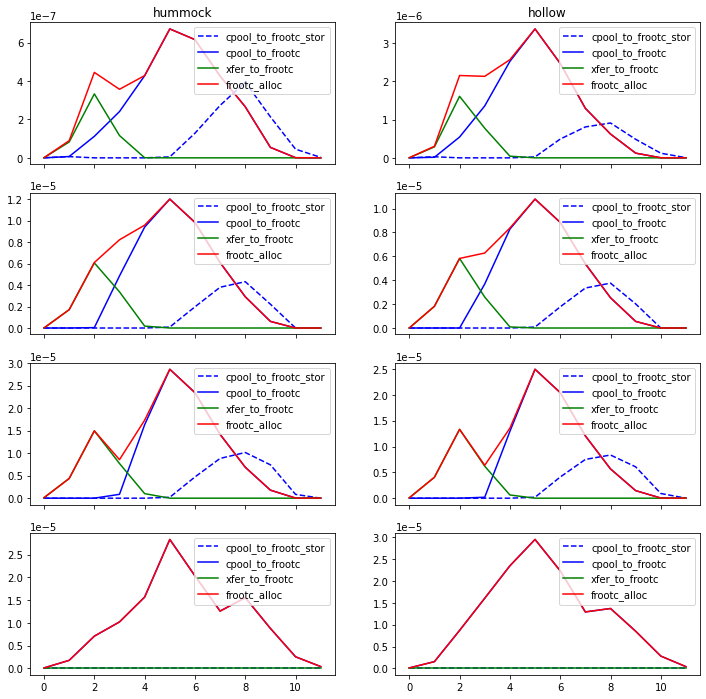

In [13]:
fig, axes = plt.subplots(4, 2, figsize = (12, 12), sharex = True, sharey = False)
for i, pft in enumerate([2, 3, 11, 12]):
    for j, loc in enumerate(['hummock', 'hollow']):
        ax = axes[i, j]
        ax.plot(hr['CPOOL_TO_FROOTC_STORAGE'].groupby('time.month').mean()[:, pft + 17*j], '--b', label = 'cpool_to_frootc_stor')
        ax.plot(hr['CPOOL_TO_FROOTC'].groupby('time.month').mean()[:, pft + 17*j], '-b', label = 'cpool_to_frootc')
        ax.plot(hr['FROOTC_XFER_TO_FROOTC'].groupby('time.month').mean()[:, pft + 17*j], '-g', label = 'xfer_to_frootc')
        ax.plot(hr['FROOTC_ALLOC'].groupby('time.month').mean()[:, pft + 17*j], '-r', label = 'frootc_alloc')
        ax.legend()

        if i == 0:
            ax.set_title(loc)

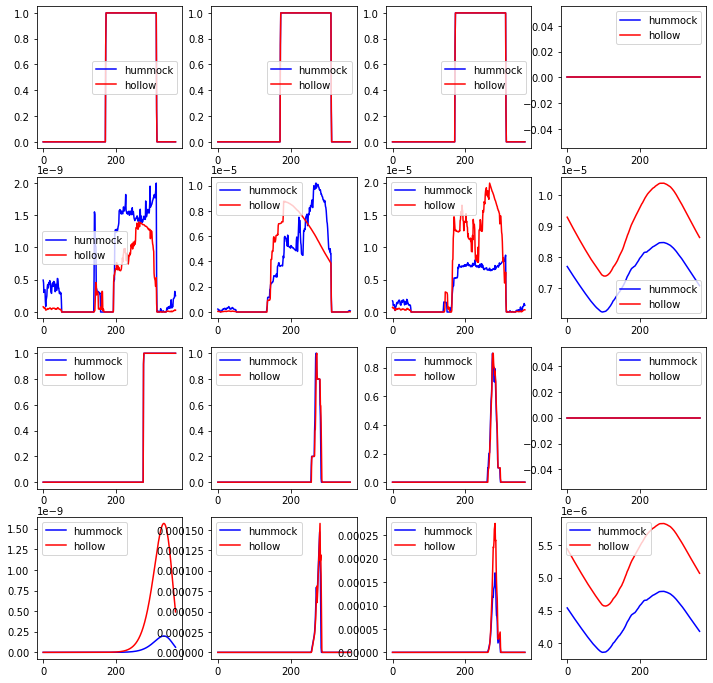

In [3]:
fig, axes = plt.subplots(4, 4, figsize = (12,12))
for i, pft in enumerate([2, 3, 11, 12]):
    ax = axes[0, i]
    ax.plot(hr['OFFSET_FLAG_ROOT'].groupby('time.dayofyear').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['OFFSET_FLAG_ROOT'].groupby('time.dayofyear').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    #ax.set_xticks(range(0, len(hr['time']), 365))

    ax = axes[1, i]
    ax.plot(hr['FROOTC_TO_LITTER'].groupby('time.dayofyear').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['FROOTC_TO_LITTER'].groupby('time.dayofyear').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    #ax.set_xticks(range(0, len(hr['time']), 365))

    ax = axes[2, i]
    ax.plot(hr['OFFSET_FLAG'].groupby('time.dayofyear').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['OFFSET_FLAG'].groupby('time.dayofyear').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    #ax.set_xticks(range(0, len(hr['time']), 365))

    ax = axes[3, i]
    ax.plot(hr['LEAFC_TO_LITTER'].groupby('time.dayofyear').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['LEAFC_TO_LITTER'].groupby('time.dayofyear').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()
    #ax.set_xticks(range(0, len(hr['time']), 365))

/bin/bash: LEAF: command not found


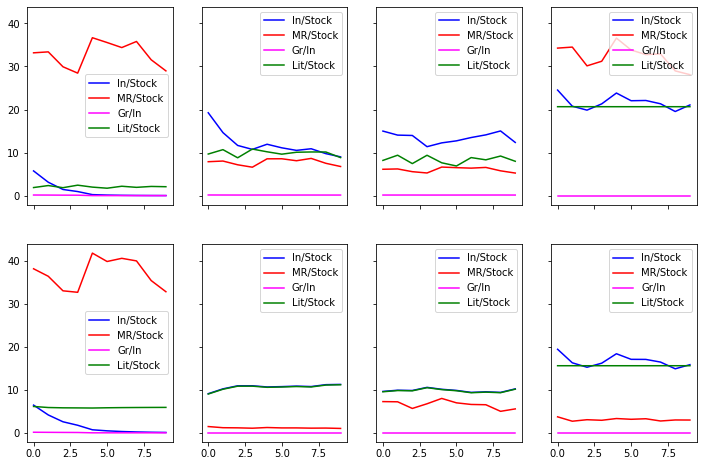

In [5]:
! LEAF LITTERFALL TO LEAFC POOL RATIO SHOULD NOT BE ThIS HIGH


fig, axes = plt.subplots(2, 4, figsize = (12, 8), sharex = True, sharey = True)
for i, pft in enumerate([2, 3, 11, 12]):

    frootc = hr['FROOTC'].resample(time = '1Y').mean()[:, pft] * 0.64 + \
             hr['FROOTC'].resample(time = '1Y').mean()[:, pft + 17] * 0.36
    frootc_stor = hr['FROOTC_STORAGE'].resample(time = '1Y').mean()[:, pft] * 0.64 + \
                  hr['FROOTC_STORAGE'].resample(time = '1Y').mean()[:, pft + 17] * 0.36
    frootc_alloc = hr['FROOTC_ALLOC'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                   hr['FROOTC_ALLOC'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_mr = hr['FROOT_MR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                hr['FROOT_MR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_gr = hr['TRANSFER_FROOT_GR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                hr['TRANSFER_FROOT_GR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_gr2 = hr['CPOOL_FROOT_GR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                 hr['CPOOL_FROOT_GR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_lit = hr['FROOTC_TO_LITTER'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                 hr['FROOTC_TO_LITTER'].resample(time = '1Y').sum()[:, pft + 17] * 0.36

    leafc = hr['LEAFC'].resample(time = '1Y').mean()[:, pft] * 0.64 + \
            hr['LEAFC'].resample(time = '1Y').mean()[:, pft + 17] * 0.36
    leafc_stor = hr['LEAFC_STORAGE'].resample(time = '1Y').mean()[:, pft] * 0.64 + \
                 hr['LEAFC_STORAGE'].resample(time = '1Y').mean()[:, pft + 17] * 0.36
    leafc_alloc = hr['LEAFC_ALLOC'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                  hr['LEAFC_ALLOC'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_mr = hr['LEAF_MR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
               hr['LEAF_MR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_gr = hr['TRANSFER_LEAF_GR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
               hr['TRANSFER_LEAF_GR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_gr2 = hr['CPOOL_LEAF_GR'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                hr['CPOOL_LEAF_GR'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_lit = hr['LEAFC_TO_LITTER'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                hr['LEAFC_TO_LITTER'].resample(time = '1Y').sum()[:, pft + 17] * 0.36

    ax = axes[0, i]
    ax.plot(frootc_alloc * 24 * 3600 / (frootc + frootc_stor), '-b', label = 'In/Stock')
    ax.plot((frootc_mr)  * 24 * 3600 / (frootc + frootc_stor), '-r', label = 'MR/Stock')
    ax.plot((frootc_gr2 + frootc_gr) / (frootc_alloc), '-', color = 'magenta', label = 'Gr/In')
    ax.plot((frootc_lit)  * 24 * 3600 / (frootc + frootc_stor), '-g', label = 'Lit/Stock')
    ax.legend()

    ax = axes[1, i]
    ax.plot(leafc_alloc  * 24 * 3600 / (leafc + leafc_stor), '-b', label = 'In/Stock')
    ax.plot((leafc_mr)  * 24 * 3600 / (leafc + leafc_stor), '-r', label = 'MR/Stock')
    ax.plot((leafc_gr2 + leafc_gr) / (leafc_alloc), '-', color = 'magenta', label = 'Gr/In')
    ax.plot((leafc_lit)  * 24 * 3600 / (leafc + leafc_stor), '-g', label = 'Lit/Stock')
    ax.legend()

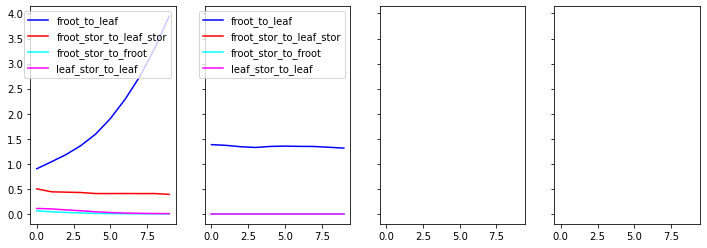

In [6]:
# root to leaf
fig, axes = plt.subplots(1, 4, figsize = (12, 4), sharex = True, sharey = True)
for i, pft in enumerate([2, 12]): # 3, 11, 

    frootc = hr['FROOTC'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
             hr['FROOTC'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    frootc_stor = hr['FROOTC_STORAGE'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                  hr['FROOTC_STORAGE'].resample(time = '1Y').sum()[:, pft + 17] * 0.36

    leafc = hr['LEAFC'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
            hr['LEAFC'].resample(time = '1Y').sum()[:, pft + 17] * 0.36
    leafc_stor = hr['LEAFC_STORAGE'].resample(time = '1Y').sum()[:, pft] * 0.64 + \
                 hr['LEAFC_STORAGE'].resample(time = '1Y').sum()[:, pft + 17] * 0.36

    ax = axes.flat[i]
    ax.plot(frootc / leafc, '-b', label = 'froot_to_leaf')
    ax.plot(frootc_stor / leafc_stor, '-r', label = 'froot_stor_to_leaf_stor')
    ax.plot(frootc_stor / frootc, '-', color = 'cyan', label = 'froot_stor_to_froot')
    ax.plot(leafc_stor / leafc, '-', color = 'magenta', label = 'leaf_stor_to_leaf')
    ax.legend()

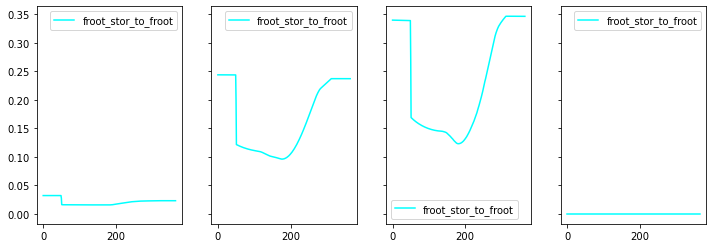

In [115]:
# root to leaf
fig, axes = plt.subplots(1, 4, figsize = (12, 4), sharex = True, sharey = True)
for i, pft in enumerate([2, 3, 11, 12]):

    frootc = hr['FROOTC'].groupby('time.dayofyear').mean()[:, pft] * 0.64 + \
             hr['FROOTC'].groupby('time.dayofyear').mean()[:, pft + 17] * 0.36
    frootc_stor = hr['FROOTC_STORAGE'].groupby('time.dayofyear').mean()[:, pft] * 0.64 + \
                  hr['FROOTC_STORAGE'].groupby('time.dayofyear').mean()[:, pft + 17] * 0.36

    leafc = hr['LEAFC'].groupby('time.dayofyear').mean()[:, pft] * 0.64 + \
            hr['LEAFC'].groupby('time.dayofyear').mean()[:, pft + 17] * 0.36
    leafc_stor = hr['LEAFC_STORAGE'].groupby('time.dayofyear').mean()[:, pft] * 0.64 + \
                 hr['LEAFC_STORAGE'].groupby('time.dayofyear').mean()[:, pft + 17] * 0.36

    ax = axes.flat[i]
    #ax.plot(frootc / leafc, '-b', label = 'froot_to_leaf')
    #ax.plot(frootc_stor / leafc_stor, '-r', label = 'froot_stor_to_leaf_stor')
    ax.plot(frootc_stor / frootc, '-', color = 'cyan', label = 'froot_stor_to_froot')
    #ax.plot(leafc_stor / leafc, '-', color = 'magenta', label = 'leaf_stor_to_leaf')
    ax.legend()

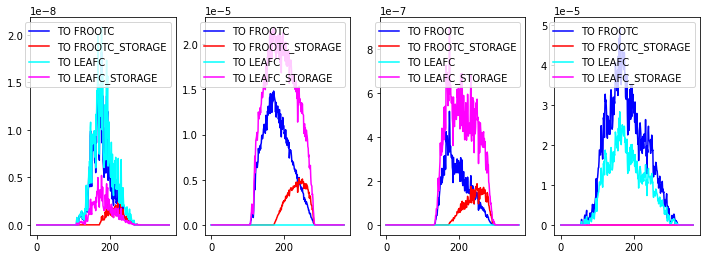

In [116]:
# allocation ratio
fig, axes = plt.subplots(1, 4, figsize = (12, 4), sharex = True, sharey = False)
for i, pft in enumerate([2, 3, 11, 12]):

    frootc = hr['CPOOL_TO_FROOTC'].groupby('time.dayofyear').mean()[:, pft] * 0.64 + \
                  hr['CPOOL_TO_FROOTC'].groupby('time.dayofyear').mean()[:, pft + 17] * 0.36
    frootc_stor = hr['CPOOL_TO_FROOTC_STORAGE'].groupby('time.dayofyear').mean()[:, pft] * 0.64 + \
             hr['CPOOL_TO_FROOTC_STORAGE'].groupby('time.dayofyear').mean()[:, pft + 17] * 0.36

    leafc = hr['CPOOL_TO_LEAFC'].groupby('time.dayofyear').mean()[:, pft] * 0.64 + \
                 hr['CPOOL_TO_LEAFC'].groupby('time.dayofyear').mean()[:, pft + 17] * 0.36
    leafc_stor = hr['CPOOL_TO_LEAFC_STORAGE'].groupby('time.dayofyear').mean()[:, pft] * 0.64 + \
            hr['CPOOL_TO_LEAFC_STORAGE'].groupby('time.dayofyear').mean()[:, pft + 17] * 0.36

    ax = axes.flat[i]
    ax.plot(frootc, '-b', label = 'TO FROOTC')
    ax.plot(frootc_stor, '-r', label = 'TO FROOTC_STORAGE')
    ax.plot(leafc, '-', color = 'cyan', label = 'TO LEAFC')
    ax.plot(leafc_stor, '-', color = 'magenta', label = 'TO LEAFC_STORAGE')
    ax.legend()

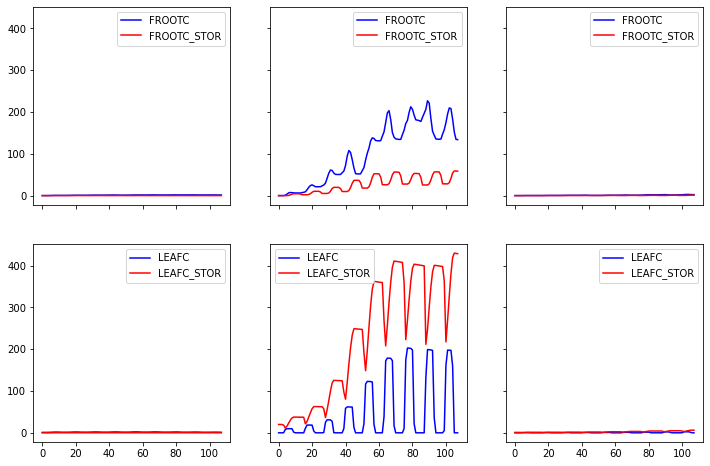

In [7]:
fig, axes = plt.subplots(2, 3, figsize = (12, 8), sharex = True, sharey = True)
for i, pft in enumerate([2, 3, 11]):

    frootc = hr['FROOTC'].resample(time = '1M').mean()[:, pft] * 0.64 + \
             hr['FROOTC'].resample(time = '1M').mean()[:, pft + 17] * 0.36
    frootc_stor = hr['FROOTC_STORAGE'].resample(time = '1M').mean()[:, pft] * 0.64 + \
                  hr['FROOTC_STORAGE'].resample(time = '1M').mean()[:, pft + 17] * 0.36

    leafc = hr['LEAFC'].resample(time = '1M').mean()[:, pft] * 0.64 + \
            hr['LEAFC'].resample(time = '1M').mean()[:, pft + 17] * 0.36
    leafc_stor = hr['LEAFC_STORAGE'].resample(time = '1M').mean()[:, pft] * 0.64 + \
                 hr['LEAFC_STORAGE'].resample(time = '1M').mean()[:, pft + 17] * 0.36

    ax = axes[0, i]
    ax.plot(frootc, '-b', label = 'FROOTC')
    ax.plot(frootc_stor, '-r', label = 'FROOTC_STOR')
    ax.legend()

    ax = axes[1, i]
    ax.plot(leafc, '-b', label = 'LEAFC')
    ax.plot(leafc_stor, '-r', label = 'LEAFC_STOR')
    ax.legend()

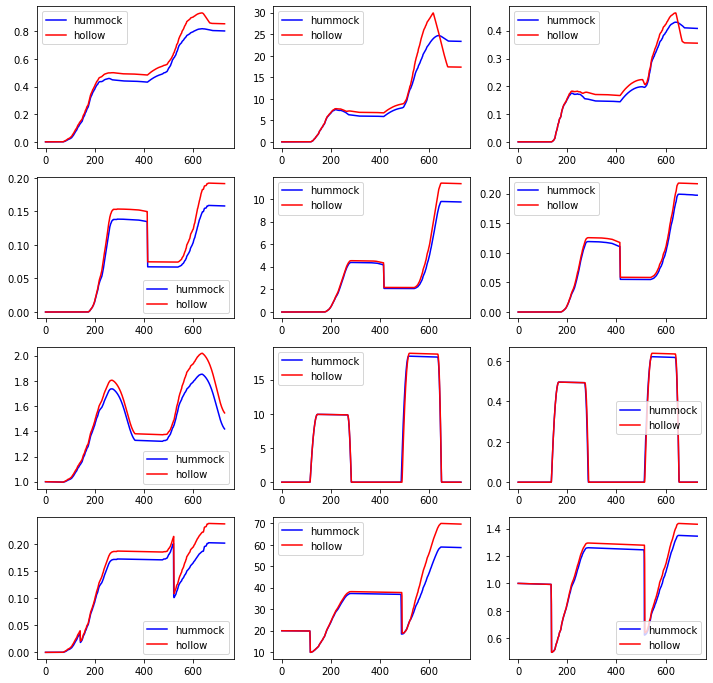

In [8]:
# carbon stock
fig, axes = plt.subplots(4, 3, figsize = (12,12))
for i, pft in enumerate([2, 3, 11]):
    ax = axes[0, i]
    ax.plot(hr['FROOTC'].resample(time = '1D').mean()[:730, pft], '-b', label = 'hummock')
    ax.plot(hr['FROOTC'].resample(time = '1D').mean()[:730, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[1, i]
    ax.plot(hr['FROOTC_STORAGE'].resample(time = '1D').mean()[:730, pft], '-b', label = 'hummock')
    ax.plot(hr['FROOTC_STORAGE'].resample(time = '1D').mean()[:730, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[2, i]
    ax.plot(hr['LEAFC'].resample(time = '1D').mean()[:730, pft], '-b', label = 'hummock')
    ax.plot(hr['LEAFC'].resample(time = '1D').mean()[:730, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[3, i]
    ax.plot(hr['LEAFC_STORAGE'].resample(time = '1D').mean()[:730, pft], '-b', label = 'hummock')
    ax.plot(hr['LEAFC_STORAGE'].resample(time = '1D').mean()[:730, pft + 17], '-r', label = 'hollow')
    ax.legend()

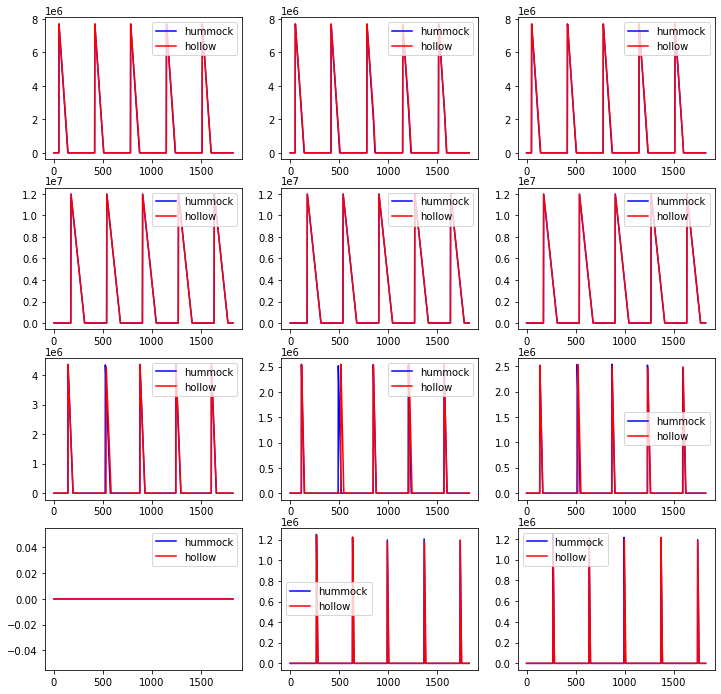

In [18]:
fig, axes = plt.subplots(4, 3, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11]):
    ax = axes[0, i]
    ax.plot(hr['ONSET_COUNTER_ROOT'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['ONSET_COUNTER_ROOT'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[1, i]
    ax.plot(hr['OFFSET_COUNTER_ROOT'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['OFFSET_COUNTER_ROOT'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[2, i]
    ax.plot(hr['ONSET_COUNTER'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['ONSET_COUNTER'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[3, i]
    ax.plot(hr['OFFSET_COUNTER'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['OFFSET_COUNTER'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

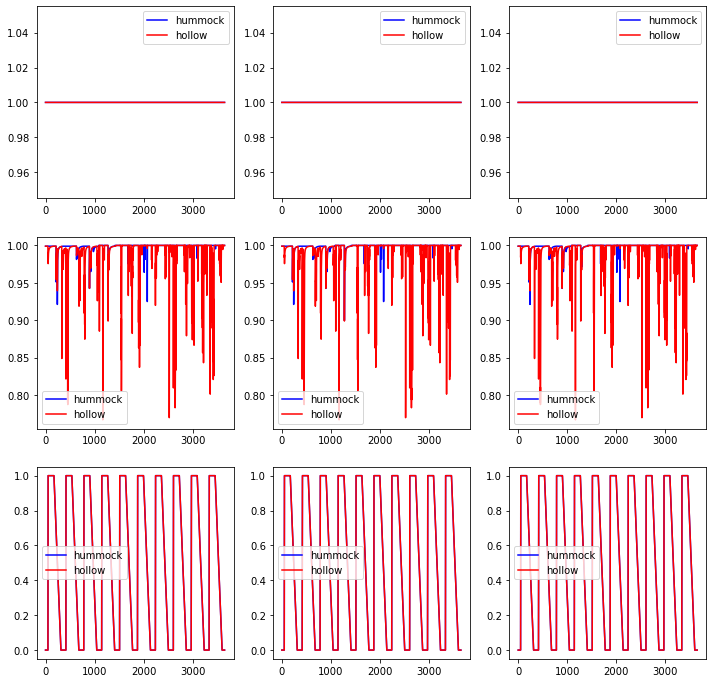

In [112]:
fig, axes = plt.subplots(3, 3, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11]):
    ax = axes[0, i]
    ax.plot(hr['ONSET_FROOT_FNMIN'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['ONSET_FROOT_FNMIN'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[1, i]
    ax.plot(hr['ONSET_FROOT_FW'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['ONSET_FROOT_FW'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    ax = axes[2, i]
    ax.plot(hr['FCUR_DYN'].resample(time = '1D').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['FCUR_DYN'].resample(time = '1D').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

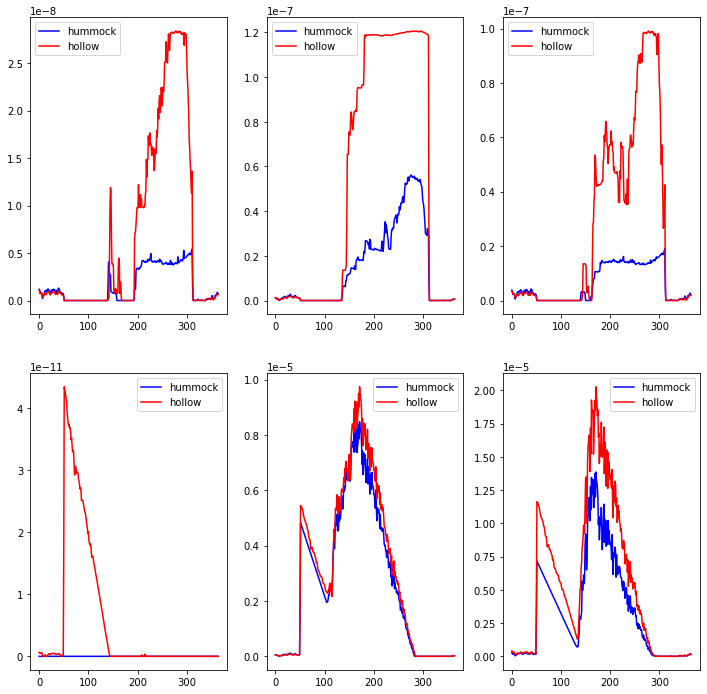

In [21]:
fig, axes = plt.subplots(2, 3, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11]):
    ax = axes[0, i]
    ax.plot(hr['BGLFR_FROOT'].groupby('time.dayofyear').mean()[:, pft], '-b', label = 'hummock')
    ax.plot(hr['BGLFR_FROOT'].groupby('time.dayofyear').mean()[:, pft + 17], '-r', label = 'hollow')
    ax.legend()

    #ax = axes[1, i]
    #ax.plot(hr['BGLFR_LEAF'].groupby('time.dayofyear').mean()[:, pft], '-b', label = 'hummock')
    #ax.plot(hr['BGLFR_LEAF'].groupby('time.dayofyear').mean()[:, pft + 17], '-r', label = 'hollow')
    #ax.legend()

    #ax = axes[1, i]
    #ax.plot(hr['BGTR'].groupby('time.dayofyear').mean()[:365, pft], '-b', label = 'hummock')
    #ax.plot(hr['BGTR'].groupby('time.dayofyear').mean()[:365, pft + 17], '-r', label = 'hollow')
    #ax.legend()

    ax = axes[1, i]
    ax.plot(hr['FROOTC_ALLOC'].groupby('time.dayofyear').mean()[:365, pft], '-b', label = 'hummock')
    ax.plot(hr['FROOTC_ALLOC'].groupby('time.dayofyear').mean()[:365, pft + 17], '-r', label = 'hollow')
    ax.legend()

In [99]:
hr['BGLFR_FROOT'][:,2].weighted(hr['FROOTC'][:,2]).mean().values, hr['BGLFR_LEAF'][:, 2].weighted(hr['LEAFC'][:,2]).mean().values, hr['BGLFR_FROOT'][:,2].mean().values, hr['BGLFR_LEAF'][:, 2].mean().values

(array(2.5918867e-09, dtype=float32),
 array(8.2944025e-09, dtype=float32),
 array(2.5501055e-09, dtype=float32),
 array(8.770144e-09, dtype=float32))

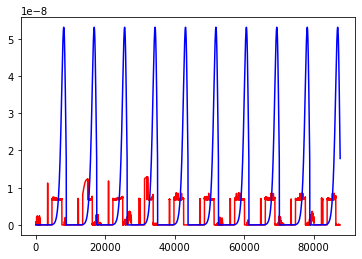

In [96]:
plt.plot(hr['BGLFR_FROOT'][:,2].values, '-r')
plt.plot(hr['BGLFR_LEAF'][:, 2].values, '-b')

In [79]:
hr['FROOTC_TO_LITTER'][:,3].values.sum(), hr['LEAFC_TO_LITTER'][:, 3].values.sum()

(0.3227034, 0.52287465)

In [78]:
hr['FROOTC_TO_LITTER'][:, 11].values.sum(), hr['LEAFC_TO_LITTER'][:, 11].values.sum()

(0.0039888904, 0.008136675)

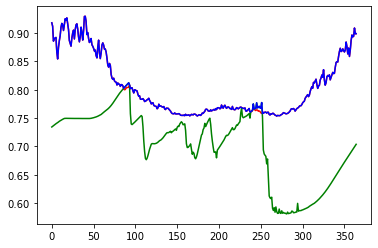

In [67]:
plt.plot(hr['LFR_FROOT_TD'][:,2].groupby('time.dayofyear').mean().values, '-r')
plt.plot(hr['LFR_FROOT_WD'][:,2].groupby('time.dayofyear').mean().values, '-g')
plt.plot(np.maximum(hr['LFR_FROOT_TD'][:,2].groupby('time.dayofyear').mean().values, 
                    hr['LFR_FROOT_WD'][:,2].groupby('time.dayofyear').mean().values), '-b')

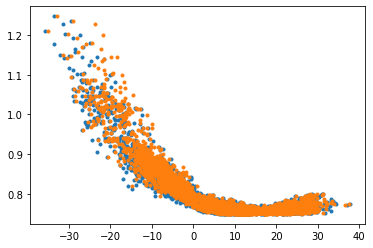

In [71]:
plt.plot(hr2['TSOI'][:, 0].values - 273.15, hr['LFR_FROOT_TD'].resample(time = '1D').mean()[:,2], '.')

(array([[  18.,   94.,  192.,  472.,  888.,  420.,  445.,  641.,  458.,
           22.],
        [  10.,   82.,  162.,  429., 1034.,  377.,  422.,  653.,  464.,
           17.]]),
 array([-35.6839   , -28.34811  , -21.012323 , -13.676535 ,  -6.340747 ,
          0.9950409,   8.330829 ,  15.666616 ,  23.002405 ,  30.338192 ,
         37.67398  ], dtype=float32),
 <a list of 2 Lists of Patches objects>)

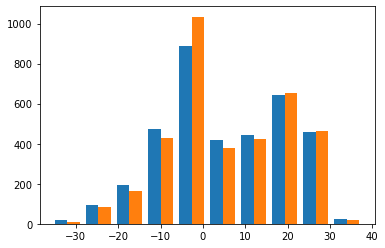

In [68]:
plt.hist(hr2['TSOI'][:, 0].values - 273.15)

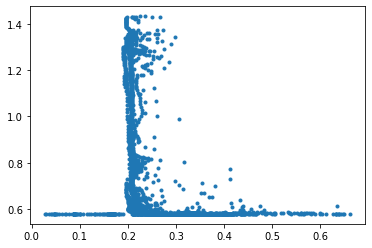

In [69]:
plt.plot(hr2['H2OSOI'][:, 3, 0], hr['LFR_FROOT_WD'].resample(time = '1D').mean()[:,2], '.')

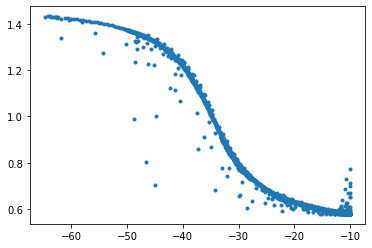

In [70]:
plt.plot(hr2['SMP'][:, :, 0].max(axis = 1), hr['LFR_FROOT_WD'].resample(time = '1D').mean()[:,2], '.')

In [ ]:
hr.close()
hr2.close()